# **26-1 YB 3조 미니 프로젝트 (2)**

팀원: 강수민, 김경민, 김나린, 김미소

## 1. 라이브러리 호출 및 데이터 불러오기

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
train = pd.read_csv('/content/drive/MyDrive/YB_data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/YB_data/test.csv')

In [44]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5497 entries, 0 to 5496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5497 non-null   int64  
 1   quality               5497 non-null   int64  
 2   fixed acidity         5497 non-null   float64
 3   volatile acidity      5497 non-null   float64
 4   citric acid           5497 non-null   float64
 5   residual sugar        5497 non-null   float64
 6   chlorides             5497 non-null   float64
 7   free sulfur dioxide   5497 non-null   float64
 8   total sulfur dioxide  5497 non-null   float64
 9   density               5497 non-null   float64
 10  pH                    5497 non-null   float64
 11  sulphates             5497 non-null   float64
 12  alcohol               5497 non-null   float64
 13  type                  5497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 601.4+ KB


In [45]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


In [46]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 1000 non-null   int64  
 1   fixed acidity         1000 non-null   float64
 2   volatile acidity      1000 non-null   float64
 3   citric acid           1000 non-null   float64
 4   residual sugar        1000 non-null   float64
 5   chlorides             1000 non-null   float64
 6   free sulfur dioxide   1000 non-null   float64
 7   total sulfur dioxide  1000 non-null   float64
 8   density               1000 non-null   float64
 9   pH                    1000 non-null   float64
 10  sulphates             1000 non-null   float64
 11  alcohol               1000 non-null   float64
 12  type                  1000 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 101.7+ KB


In [47]:
test.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,white
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,red
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,white
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,white
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,white


<Axes: >

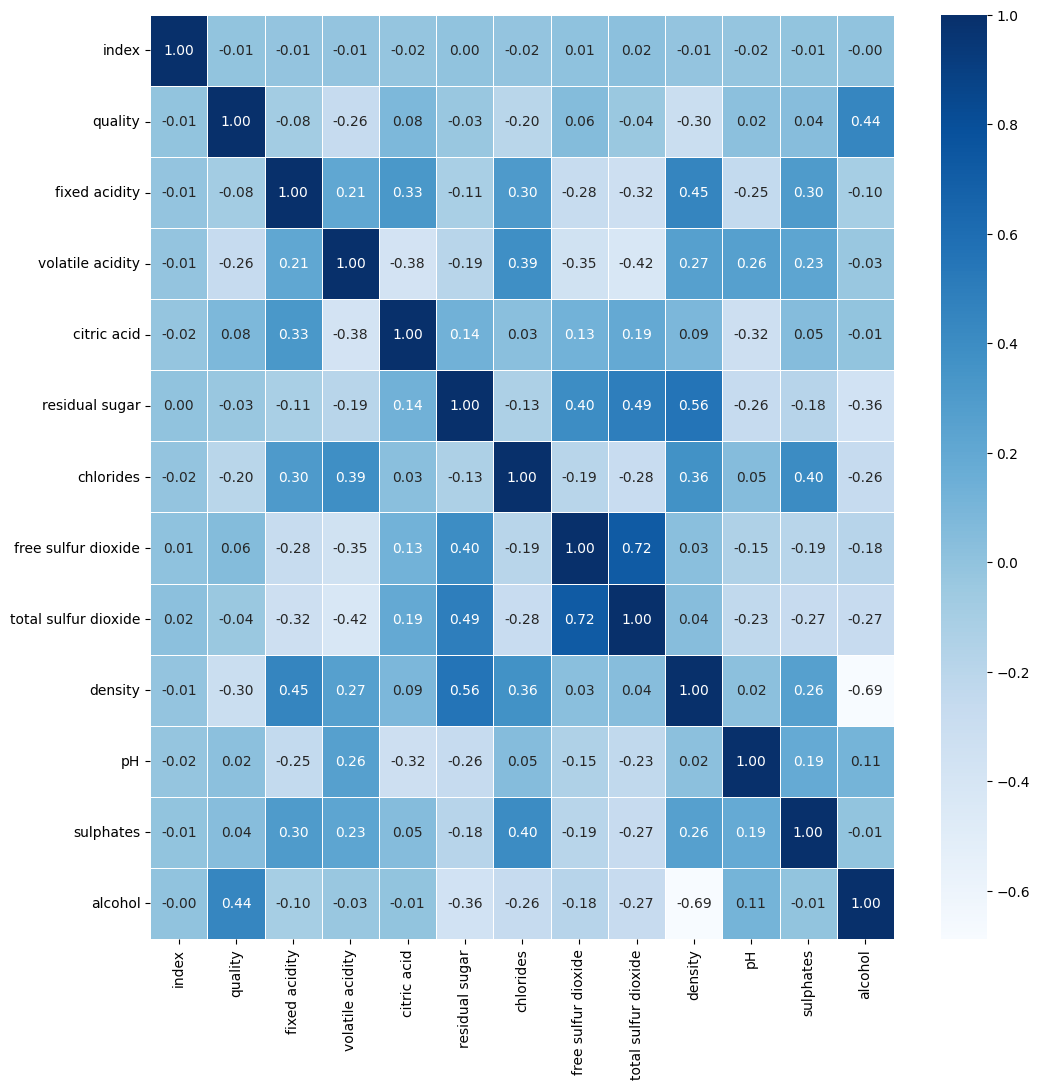

In [48]:
plt.figure(figsize=(12,12))
sns.heatmap(data = train.corr(numeric_only=True), annot=True, fmt = '.2f', linewidths=.5, cmap='Blues')

/tmp/ipykernel_8923/75114489.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.iloc[:,i])
/tmp/ipykernel_8923/75114489.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.iloc[:,i])
/tmp/ipykernel_8923/75114489.py:5: UserWarning: 

`distplot` is a deprecated function and will be re

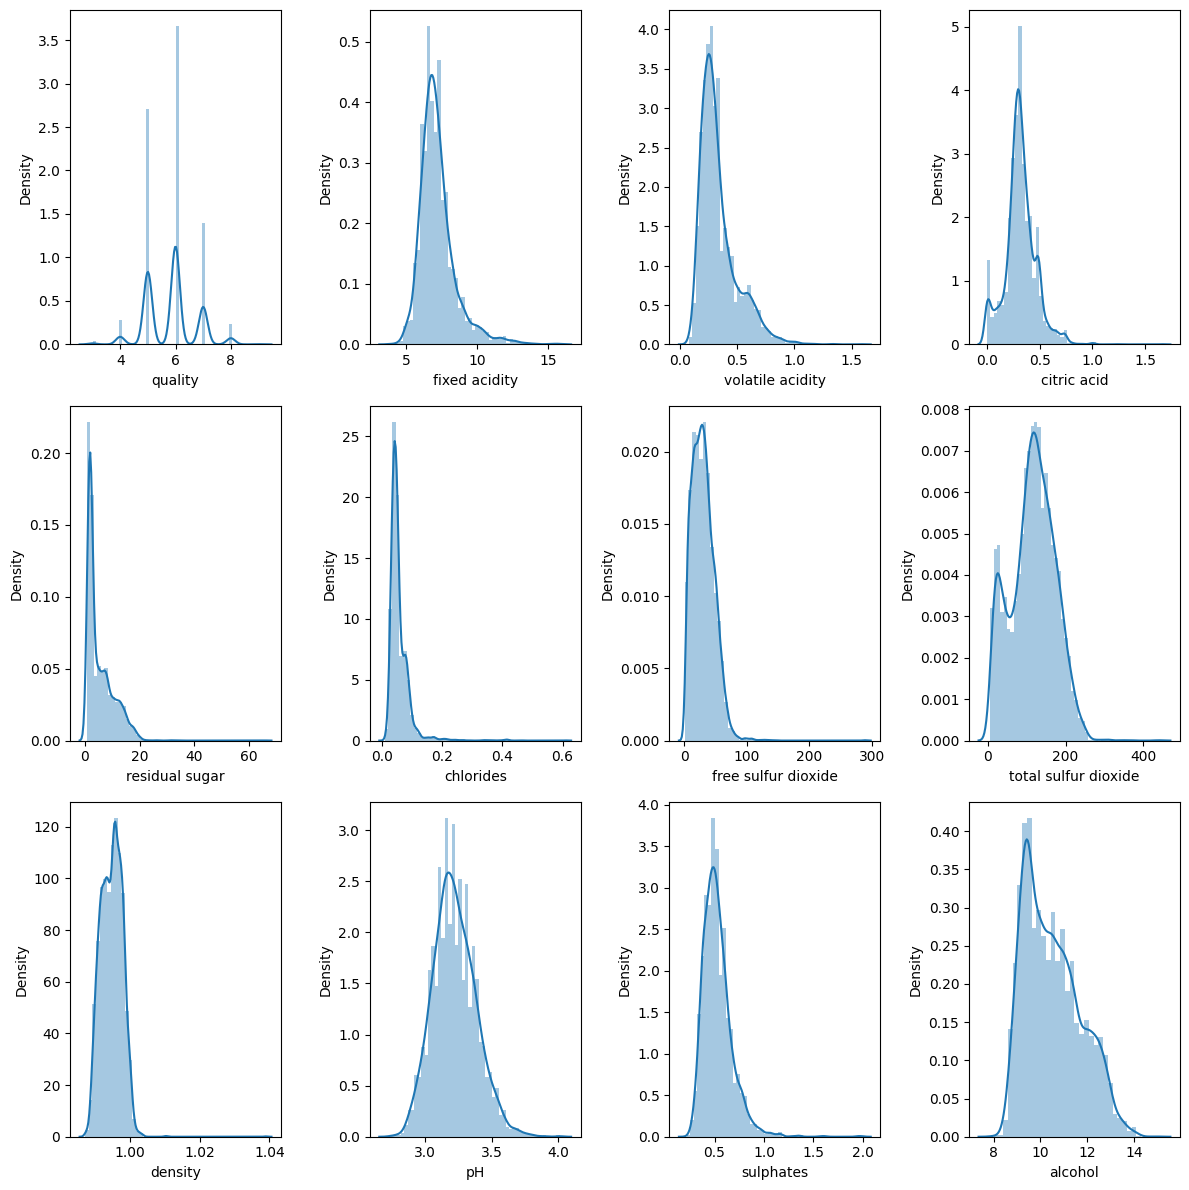

In [49]:
# train의 각 변수별 분포를 살펴봅니다.
plt.figure(figsize=(12,12))
for i in range(1,13):
    plt.subplot(3,4,i)
    sns.distplot(train.iloc[:,i])
plt.tight_layout()
plt.show()

## 3. 데이터 전처리 (Preprocessing) 및 검증 세트 분리

In [50]:
le = LabelEncoder()
train['type'] = le.fit_transform(train['type'])
test['type'] = le.transform(test['type'])

X_features = train.drop(['index', 'quality'], axis=1)
y_label = train['quality']
X_test_final = test.drop(['index'], axis=1)

le_y = LabelEncoder()
y_label = le_y.fit_transform(train['quality'])

X_train, X_val, y_train, y_val = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156)

In [51]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,1
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,0
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,1
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,1
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,1


## 4. 모델 학습 및 검증

### **LightGBM**

In [52]:
lgbm_clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    random_state=156,
    verbosity=-1
)

lgbm_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 결과 확인
preds = lgbm_clf.predict(X_val)
print(f"\n최종 검증 정확도: {accuracy_score(y_val, preds):.4f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[158]	valid_0's multi_logloss: 0.937544

최종 검증 정확도: 0.6600


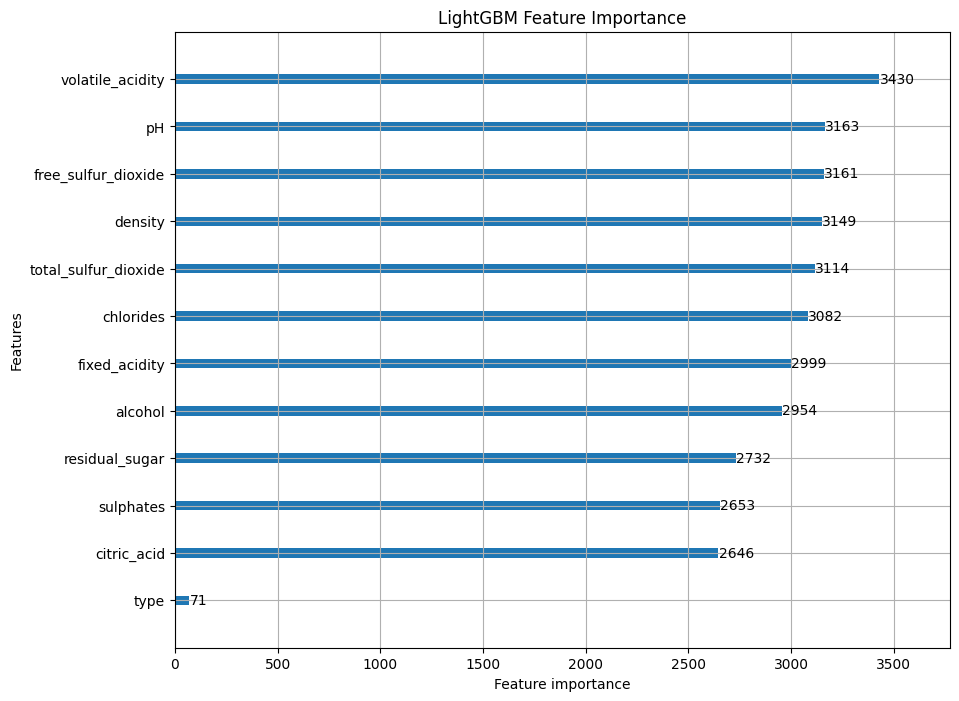

In [53]:
from lightgbm import plot_importance

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(lgbm_clf, ax=ax)
plt.title('LightGBM Feature Importance')
plt.show()

### **XGBoost**

In [54]:
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.model_selection import GridSearchCV

# GridSearchCV로 최적 하이퍼 파라미터 찾기
param_grid = {'max_depth' : [12, 13],
              'subsample' : [0.8],
              'gamma': [0],
              'learning_rate': [0.05]}

xgb_base = XGBClassifier(n_estimators = 400, eval_metric = 'mlogloss', random_state = 156)

grid_search = GridSearchCV(estimator = xgb_base, param_grid = param_grid,
                           cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)

grid_search.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최고 정확도:", grid_search.best_score_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


최적 하이퍼파라미터: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 12, 'subsample': 0.8}
최고 정확도: 0.6415673802875168


In [55]:
# 최종 모델 학습
xgb_wrapper = XGBClassifier(n_estimators = 400, early_stopping_rounds = 100,
                            eval_metric = 'mlogloss', learning_rate = 0.05,
                            max_depth = 12, gamma = 0, subsample = 0.8,
                            random_state = 156)

evals = [(X_train, y_train), (X_val, y_val)]
xgb_wrapper.fit(X_train, y_train, eval_set=evals, verbose=True)

[0]	validation_0-mlogloss:1.23253	validation_1-mlogloss:1.24252
[1]	validation_0-mlogloss:1.19180	validation_1-mlogloss:1.22311
[2]	validation_0-mlogloss:1.15457	validation_1-mlogloss:1.20451
[3]	validation_0-mlogloss:1.11878	validation_1-mlogloss:1.18703
[4]	validation_0-mlogloss:1.08566	validation_1-mlogloss:1.17039
[5]	validation_0-mlogloss:1.05399	validation_1-mlogloss:1.15492
[6]	validation_0-mlogloss:1.02441	validation_1-mlogloss:1.14112
[7]	validation_0-mlogloss:0.99495	validation_1-mlogloss:1.12684
[8]	validation_0-mlogloss:0.96783	validation_1-mlogloss:1.11494
[9]	validation_0-mlogloss:0.94189	validation_1-mlogloss:1.10259
[10]	validation_0-mlogloss:0.91760	validation_1-mlogloss:1.09142
[11]	validation_0-mlogloss:0.89427	validation_1-mlogloss:1.07952
[12]	validation_0-mlogloss:0.87036	validation_1-mlogloss:1.06873
[13]	validation_0-mlogloss:0.84852	validation_1-mlogloss:1.05870
[14]	validation_0-mlogloss:0.82691	validation_1-mlogloss:1.04859
[15]	validation_0-mlogloss:0.80691	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [56]:
val_preds = xgb_wrapper.predict(X_val)
print("검증 데이터 정확도:", accuracy_score(y_val, val_preds))

검증 데이터 정확도: 0.6918181818181818


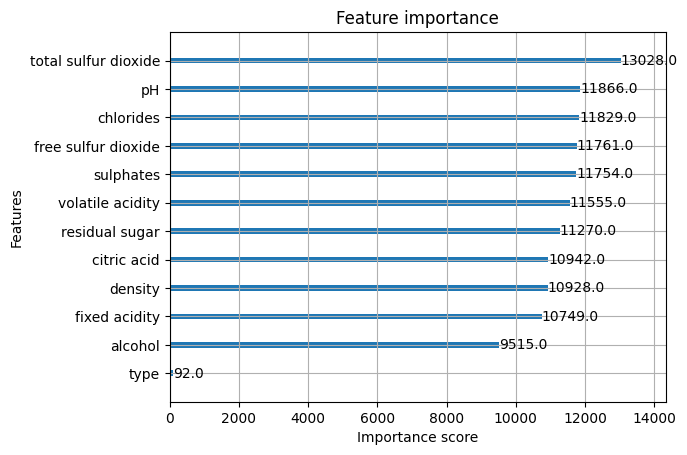

In [57]:
# 변수 중요도
import matplotlib.pyplot as plt
plot_importance(xgb_wrapper)
plt.show()

### **Random Forest+XGBoost**

In [58]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Initialize Stratified K-Fold
n_splits = 5  # You can change the number of splits
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=156)

# Initialize an empty list to store fold accuracies
fold_accuracies = []

# Perform Stratified K-Fold cross-validation
for fold, (train_index, val_index) in enumerate(skf.split(X_features, y_label)):
    print(f"\n----- Fold {fold+1}/{n_splits} -----")
    X_train_fold, X_val_fold = X_features.iloc[train_index], X_features.iloc[val_index]
    y_train_fold, y_val_fold = y_label[train_index], y_label[val_index]

    # Initialize RandomForestClassifier for each fold
    rf_model = RandomForestClassifier(n_estimators=100, random_state=156, n_jobs=-1)

    # Train the model
    rf_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = rf_model.predict(X_val_fold)

    # Calculate and store accuracy
    accuracy = accuracy_score(y_val_fold, y_pred_fold)
    fold_accuracies.append(accuracy)
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")

# Print average accuracy across all folds
print(f"\nAverage Stratified K-Fold Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Standard Deviation of Stratified K-Fold Accuracy: {np.std(fold_accuracies):.4f}")


----- Fold 1/5 -----
Fold 1 Accuracy: 0.6673

----- Fold 2/5 -----
Fold 2 Accuracy: 0.6609

----- Fold 3/5 -----
Fold 3 Accuracy: 0.6924

----- Fold 4/5 -----
Fold 4 Accuracy: 0.6797

----- Fold 5/5 -----
Fold 5 Accuracy: 0.6670

Average Stratified K-Fold Accuracy: 0.6735
Standard Deviation of Stratified K-Fold Accuracy: 0.0113


In [59]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# Initialize individual models
rf_clf = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, random_state=42)
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.07, max_depth=15, random_state=42, verbose=-1)

# Create a VotingClassifier
voting_clf = VotingClassifier(estimators=[
    ('rf', rf_clf),
    ('xgb', xgb_clf)
], voting='soft', n_jobs=-1) # 'soft' voting for probability-based averaging

# Fit the ensemble model
voting_clf.fit(X_train, y_train)

# Make predictions on the validation set
preds = voting_clf.predict(X_val)

# Print the accuracy score
print(f"\n앙상블 모델(Random Forest + XGBoost) 최종 검증 정확도: {accuracy_score(y_val, preds):.4f}")


앙상블 모델(Random Forest + XGBoost) 최종 검증 정확도: 0.6918


## 5. 최종 앙상블 모델

### **Random Forest+XGBoost+LightGBM**

In [60]:
# 데이터 전처리 수정을 위해 다시 데이터프레임 로딩
train = pd.read_csv('/content/drive/MyDrive/YB_data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/YB_data/test.csv')

In [61]:
# 컬럼명 공백을 언더바(_)로 변경 및 불필요한 index 분리
train.columns = [c.replace(' ', '_') for c in train.columns]
test.columns = [c.replace(' ', '_') for c in test.columns]

train = train.drop('index', axis=1, errors='ignore')
test_index = test['index']
test = test.drop('index', axis=1, errors='ignore')

# 범주형 변수(type) 라벨 인코딩
le_type = LabelEncoder()
train['type'] = le_type.fit_transform(train['type'])
test['type'] = le_type.transform(test['type'])

# 고급 파생 변수 생성 (정확도 극대화)
def advanced_features(df):
    df_copy = df.copy()
    df_copy['total_acidity'] = df_copy['fixed_acidity'] + df_copy['volatile_acidity']
    df_copy['alcohol_density'] = df_copy['alcohol'] * df_copy['density']
    df_copy['sugar_to_acidity'] = df_copy['residual_sugar'] / (df_copy['total_acidity'] + 1e-9)
    df_copy['free_so2_ratio'] = df_copy['free_sulfur_dioxide'] / (df_copy['total_sulfur_dioxide'] + 1e-9)
    return df_copy

train = advanced_features(train)
test = advanced_features(test)

#  독립변수(X)와 종속변수(y) 분리 및 타겟 변수 라벨 인코딩
X = train.drop('quality', axis=1)
y = train['quality']

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

#  데이터 스케일링 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test)

print("데이터 전처리 및 스케일링 완료")

데이터 전처리 및 스케일링 완료


In [64]:
print("학습 준비 및 검증 세트 분리")

# 전체 데이터의 20%를 검증용으로 분리 (stratify를 통해 각 품질 등급 비율 유지)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("학습용 데이터 크기:", X_train.shape)
print("검증용 데이터 크기:", X_val.shape)

학습 준비 및 검증 세트 분리
학습용 데이터 크기: (4397, 16)
검증용 데이터 크기: (1100, 16)


In [71]:
print("분류 모델 학습 및 평가")

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred)
print(f"1. Random Forest 정확도: {rf_acc:.4f}")

# LightGBM
lgbm_clf = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=15, num_leaves=31, random_state=42, verbose=-1)
lgbm_clf.fit(X_train, y_train)
lgbm_pred = lgbm_clf.predict(X_val)
lgbm_acc = accuracy_score(y_val, lgbm_pred)
print(f"2. LightGBM 정확도: {lgbm_acc:.4f}")

# XGBoost
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=10, subsample=0.8, colsample_bytree=0.8, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
xgb_pred = xgb_clf.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_pred)
print(f"3. XGBoost 정확도: {xgb_acc:.4f}")

print("\n 소프트 보팅 앙상블 (Weighted Soft Voting) 적용")
# 세 모델 중 가장 점수가 잘 나온 모델에게 가중치 주는 앙상블
voting_clf = VotingClassifier(
    estimators=[('RF', rf_clf), ('LGBM', lgbm_clf), ('XGB', xgb_clf)],
    voting='soft',
    weights=[2.0, 2.0, 3.0]
)
voting_clf.fit(X_train, y_train)
val_pred = voting_clf.predict(X_val)
print(f"최종 앙상블 정확도: {accuracy_score(y_val, val_pred):.4f}")

분류 모델 학습 및 평가
1. Random Forest 정확도: 0.6591


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


2. LightGBM 정확도: 0.6409


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:56:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


3. XGBoost 정확도: 0.6482

 소프트 보팅 앙상블 (Weighted Soft Voting) 적용


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


최종 앙상블 정확도: 0.6573


## 6. 결과 제출

In [72]:
print("최종 예측 및 제출용(Submission) 파일 생성")

# 리더보드 최고점을 위해 분할하기 전 전체 데이터(X_scaled)로 재학습
voting_clf.fit(X_scaled, y_encoded)

# 실제 테스트 데이터 예측
test_pred_encoded = voting_clf.predict(test_scaled)

# 0~6으로 변환되었던 타겟값을 원래의 와인 품질 등급(3~9)으로 원상 복구
test_pred_original = le_y.inverse_transform(test_pred_encoded)

# 데이콘 제출 양식에 맞게 DataFrame 생성
submission = pd.DataFrame({'index': test_index,'quality': test_pred_original})

# 지정된 경로에 CSV 파일 저장
submission_path = '/content/drive/MyDrive/submission_final.csv'
submission.to_csv(submission_path, index=False)

print(f"제출용 파일 생성 완료. \n파일 위치: {submission_path}")

최종 예측 및 제출용(Submission) 파일 생성


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


제출용 파일 생성 완료. 
파일 위치: /content/drive/MyDrive/submission_final.csv
